In [2]:
# from analyse_results/decode_ana.ipynb
# interim_sum_data/...csv files created in behavior/nlc-model1_post.ipynb

import pandas as pd
import os.path as op
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
import pingouin # need numrefields env

bids_folder = '/Users/mrenke/data/ds-stressrisk'
model_folder = op.join(bids_folder, 'derivatives', 'cogmodels')


In [3]:
df_decod = pd.read_csv('/Users/mrenke/data/ds-stressrisk/interim_sum_data/within-ses-decod_r-sds.csv')
df_decod = df_decod.set_index(['subject','session'])

In [26]:
df_decod_r = pd.read_csv('/Users/mrenke/data/ds-stressrisk/interim_sum_data/decoding_accuracy_allSub_allSes.csv')
df_decod_r = df_decod_r.set_index(['subject','session'])


group       sds         r
subject session                             
1       1        control  0.297518  0.038720
2       1        control  0.363510 -0.020221
        2        control  0.383693 -0.037180
3       1         stress  0.321775  0.040654
        2         stress  0.363966  0.092999

In [4]:
df_ev_sd = pd.read_csv('/Users/mrenke/data/ds-stressrisk/interim_sum_data/noises_model-6.csv')
df_ev_sd = df_ev_sd.set_index(['subject','session'])

df_comb = df_decod.join(df_ev_sd) # df_decod_r.join(df_ev_sd)
df_comb = df_comb.xs(1,0,'session') # only look at session 1 for now


/Users/mrenke/mambaforge/envs/numrefields/lib/python3.10/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package outdated is out of date. Your version is 0.2.1, the latest is 0.2.2.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(
/Users/mrenke/mambaforge/envs/numrefields/lib/python3.10/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.2, the latest is 0.5.3.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


In [5]:
df_n1_ev_sd = pd.read_csv('/Users/mrenke/data/ds-stressrisk/interim_sum_data/subwise_seswise_n1_evidence_sd.csv').set_index(['subject','session'])
df_n2_ev_sd = pd.read_csv('/Users/mrenke/data/ds-stressrisk/interim_sum_data/subwise_seswise_n2_evidence_sd.csv').set_index(['subject','session'])


In [6]:
df_comb = df_comb.join(df_n2_ev_sd).join(df_n1_ev_sd)
df_comb = df_comb.xs(1,0,'session')

In [7]:
df_comb.head()

,group,sds,r,memory_noise_sd,perceptual_noise_sd,n2_evidence_sd,n1_evidence_sd
subject,,,,,,,
1,control,0.297518,0.038720,-1.864682,-1.813338,0.153327,0.324216
2,control,0.363510,-0.020221,-2.577539,-1.580378,0.224862,0.315138
5,control,0.357436,0.240643,-1.993019,-1.691597,0.175523,0.330258
9,control,0.349030,0.090306,-2.408638,-1.480638,0.244093,0.326566
10,control,0.327351,0.185421,-2.439944,-1.592414,0.204378,0.316187


In [8]:
df_comb['mem+per_noise'] = df_comb['perceptual_noise_sd'] + df_comb['memory_noise_sd']

Text(0.5, 1.0, 'r=-0.19, p= 0.1862')

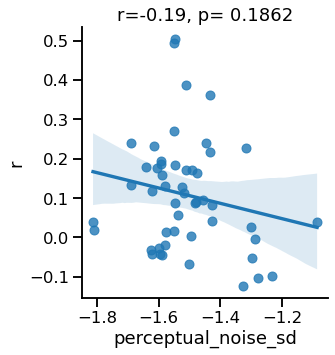

In [10]:
# plot
sns.set_context('talk')

var1 = 'perceptual_noise_sd'#'mem+per_noise' # 'n2_evidence_sd'#'memory_noise_sd' # 'perceptual_noise_sd 'perceptual_noise_sd' #
var2 = 'r' #'r' #'sds' # 'n2_evidence_sd'

sns.lmplot(x=var1,y=var2, data=df_comb )

cor = pingouin.corr(df_comb[var1], df_comb[var2])
r = np.round(cor['r'][0], 2)
p = np.round(cor['p-val'][0], 5)
plt.title(f'r={r}, p= {p}')